In [16]:
# ── 0. Install & imports ──────────────────────────────────────────────────────

!pip install -q earth2studio[stormcast]

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import earth2studio.run as run

from datetime import datetime
from scipy.interpolate import RegularGridInterpolator
from earth2studio.models.px import StormCast
from earth2studio.data import GFS_FX
from earth2studio.io import ZarrBackend

In [17]:
# ── 1. Constants ──────────────────────────────────────────────────────────────

# load model to access variable names and HRRR coordinate system
package = StormCast.load_default_package()
model = StormCast.load_model(package, conditioning_data_source=GFS_FX())

coords = model.input_coords()

VARIABLES = list(coords["variable"])
HRRR_Y = np.asarray(coords["hrrr_y"])
HRRR_X = np.asarray(coords["hrrr_x"])

NY = len(HRRR_Y)
NX = len(HRRR_X)

print("NY, NX:", NY, NX)
print("hrrr_y range:", HRRR_Y.min(), HRRR_Y.max())
print("hrrr_x range:", HRRR_X.min(), HRRR_X.max())

# VARIABLES = [
#     'v20hl', 'q1hl',  'u3hl',  't2m',   'u20hl', 'v25hl', 'v5hl',  'Z2hl',
#     'v9hl',  'p6hl',  'Z3hl',  'u10m',  't1hl',  't9hl',  'p4hl',  'Z5hl',
#     'u10hl', 'v10m',  'q7hl',  'Z20hl', 'u6hl',  'Z6hl',  'q20hl', 'v10hl',
#     't4hl',  'Z4hl',  'q30hl', 'p15hl', 'p2hl',  'q15hl', 'p7hl',  'Z25hl',
#     'p3hl',  'p20hl', 't7hl',  't30hl', 'u1hl',  't2hl',  't11hl', 'p1hl',
#     'q4hl',  't15hl', 'v2hl',  'p11hl', 'p8hl',  'v11hl', 'Z10hl', 'Z30hl',
#     't3hl',  'v1hl',  'Z9hl',  'q11hl', 'Z11hl', 't20hl', 'p5hl',  'q8hl',
#     'q5hl',  'u4hl',  't13hl', 'p9hl',  'q25hl', 'Z13hl', 'p13hl', 'v30hl',
#     'q9hl',  'v4hl',  'mslp',  'q3hl',  'q13hl', 'Z15hl', 't10hl', 'refc',
#     'Z7hl',  'Z1hl',  'p10hl', 'u8hl',  'u25hl', 'v8hl',  'u15hl', 'v15hl',
#     'u2hl',  'q2hl',  'u11hl', 't5hl',  'v3hl',  'Z8hl',  't8hl',  't25hl',
#     'u7hl',  'u5hl',  'u30hl', 'u9hl',  'v6hl',  'q10hl', 'v13hl', 'u13hl',
#     'q6hl',  't6hl',  'v7hl',
# ]

NY, NX: 512 640
hrrr_y range: -768306.1525566636 764693.8474433364
hrrr_x range: -960520.1425219304 956479.8574780696


In [18]:
# ── 2. MyLocalData ────────────────────────────────────────────────────────────

class MyLocalData:
    """
    Wraps a local numpy array into the xarray interface expected by earth2studio.

    Args:
        data:      numpy array of shape (nt, ny, nx, nc)
        variables: list of nc variable name strings matching StormCast's expected inputs
        lats:      1D array of length ny — y-coordinate values (hrrr_y)
        lons:      1D array of length nx — x-coordinate values (hrrr_x)
        times:     list of nt datetimes, one per time slice in data
    """

    def __init__(
        self,
        data: np.ndarray,
        variables: list[str],
        hrrr_y: np.ndarray,
        hrrr_x: np.ndarray,
        times: list[datetime],
    ):
        nt, ny, nx, nc = data.shape
        assert len(times) == nt,      f"Expected {nt} timestamps, got {len(times)}"
        assert len(variables) == nc,  f"Expected {nc} variable names, got {len(variables)}"
        assert len(hrrr_y) == ny and len(hrrr_x) == nx, "hrrr_y/hrrr_x size mismatch with data grid"

        self.data      = data
        self.variables = variables
        self.hrrr_y = hrrr_y
        self.hrrr_x = hrrr_x
        self.times     = times

    def __call__(self, time: list[datetime], variable: list[str] | str) -> xr.DataArray:
        if isinstance(variable, str):
            variable = [variable]

        t_idx = self.times.index(time[0]) if time[0] in self.times else 0

        da = xr.DataArray(
            self.data[t_idx][np.newaxis, ...],   # (1, ny, nx, nc)
            dims=["time", "hrrr_y", "hrrr_x", "variable"],
            coords={
                "time":     [time[0]],
                "hrrr_y":   self.hrrr_y,
                "hrrr_x":   self.hrrr_x,
                "variable": self.variables,
            },
        )
        return da.sel(variable=variable).transpose("time", "variable", "hrrr_y", "hrrr_x")

In [19]:
# ── 3. Regridding helper ──────────────────────────────────────────────────────

def regrid(field: np.ndarray, src_lats: np.ndarray, src_lons: np.ndarray,
           target_lats: np.ndarray, target_lons: np.ndarray) -> np.ndarray:
    """
    Bilinearly interpolate a 2D field (nlat, nlon) from a source lat/lon grid
    onto a target lat/lon grid using scipy's RegularGridInterpolator.

    src_lats must be 1D and can be in any order — they are sorted internally.
    Returns a 2D array of shape (len(target_lats), len(target_lons)).
    """
    # RegularGridInterpolator requires ascending coordinates
    if src_lats[0] > src_lats[-1]:
        src_lats = src_lats[::-1]
        field    = field[::-1, :]

    interp_fn = RegularGridInterpolator(
        (src_lats, src_lons), field,
        method="linear", bounds_error=False, fill_value=np.nan,
    )

    grid_lons, grid_lats = np.meshgrid(target_lons, target_lats)
    points = np.stack([grid_lats.ravel(), grid_lons.ravel()], axis=-1)
    return interp_fn(points).reshape(len(target_lats), len(target_lons))

In [20]:
# ── 4. Build input array ──────────────────────────────────────────────────────

# Target grid — shared by all variables
ds_era5 = xr.open_dataset("/content/directly_transferrable_variables.nc")
src_lats = ds_era5.latitude.values
src_lons = ds_era5.longitude.values
target_lats = np.linspace(src_lats.max(), src_lats.min(), NY)
target_lons = np.linspace(src_lons.min(), src_lons.max(), NX)

# Initialise with zeros (placeholder for variables not yet mapped)
data = np.zeros((1, NY, NX, len(VARIABLES)), dtype=np.float32)


# ERA5 to StormCast variable insertion
ERA5_TO_STORMCAST = {
    "t2m": "t2m",
    "u10": "u10m",
    "v10": "v10m",
    "msl": "mslp",
}

for era5_name, stormcast_name in ERA5_TO_STORMCAST.items():
    raw = ds_era5[era5_name].isel(valid_time=0).values.astype(np.float32)

    regridded = regrid(
        field=raw,
        src_lats=src_lats,
        src_lons=src_lons,
        target_lats=target_lats,
        target_lons=target_lons,
    ).astype(np.float32)

    if np.isnan(regridded).any():
        raise ValueError(f"NaNs found after regridding {era5_name} → {stormcast_name}")

    idx = VARIABLES.index(stormcast_name)
    data[0, :, :, idx] = regridded

    print(
        f"{era5_name:4s} → {stormcast_name:5s} | "
        f"min={regridded.min():.2f}, "
        f"max={regridded.max():.2f}, "
        f"mean={regridded.mean():.2f}"
    )

t2m  → t2m   | min=288.05, max=301.83, mean=299.10
u10  → u10m  | min=-8.33, max=8.06, mean=-0.33
v10  → v10m  | min=-6.74, max=5.00, mean=-1.40
msl  → mslp  | min=100767.06, max=101442.03, mean=100965.23


In [21]:
# ── 5. Wrap and verify ────────────────────────────────────────────────────────

STARTING_TIME = np.datetime64(ds_era5.valid_time.values[0], "ns")

my_data = MyLocalData(
    data=data,
    variables=VARIABLES,
    hrrr_y=HRRR_Y,
    hrrr_x=HRRR_X,
    times=[STARTING_TIME],
)

sample = my_data([STARTING_TIME], VARIABLES)
print("Sample dims: ", sample.dims)
print("Sample shape:", sample.shape)

Sample dims:  ('time', 'variable', 'hrrr_y', 'hrrr_x')
Sample shape: (1, 99, 512, 640)


In [22]:
# ── 6. Inference ──────────────────────────────────────────────────────────────

io = ZarrBackend("stormcast_output_era5.zarr", backend_kwargs={"overwrite": True})
io = run.deterministic(time=[STARTING_TIME], nsteps=2, prognostic=model, data=my_data, io=io)

2026-05-28 01:56:25.276 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-28 01:56:25.276 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda
2026-05-28 01:56:26.395 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from MyLocalData
2026-05-28 01:56:27.044 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-28 01:56:32.451 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 402200616-968574
2026-05-28 01:56:32.546 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 261515963-813586




Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-28 01:56:32.672 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 345504734-941534
2026-05-28 01:56:32.788 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 208633688-736901
2026-05-28 01:56:32.846 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 267790775-926949


...

2026-05-28 01:57:56.755 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f001 264290309-813603
2026-05-28 01:57:56.793 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f001 270546706-929529
2026-05-28 01:57:56.830 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f001 210725381-736978
2026-05-28 01:57:56.866 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f001 0-1008366
2026-05-28 01:57:56.904 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f001 400232447-860246
2026-05-28 01:57:56.942 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib fi



Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data: 100%|██████████| 26/26 [00:01<00:00, 25.37it/s]


2026-05-28 01:57:56.983 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f001 342371536-846761
2026-05-28 01:57:57.023 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f001 406189544-958512
2026-05-28 01:57:57.063 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f001 265103912-725378



Running inference: 100%|██████████| 3/3 [02:49<00:00, 56.45s/it]

2026-05-28 01:59:16.403 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


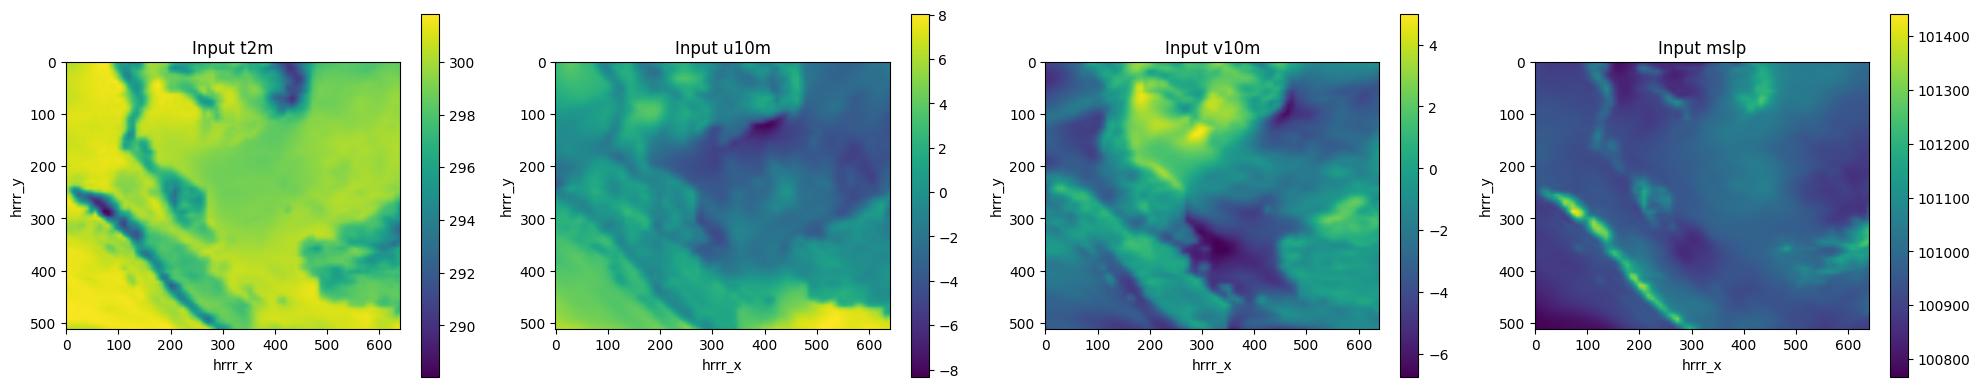

In [23]:
# ── 7. Plot input ────────────────────────────────────────────────────────────

INPUT_PLOT_VARIABLES = ["t2m", "u10m", "v10m", "mslp"]

fig, axes = plt.subplots(1, len(INPUT_PLOT_VARIABLES), figsize=(5 * len(INPUT_PLOT_VARIABLES), 4))

for ax, var_name in zip(axes, INPUT_PLOT_VARIABLES):
    idx = VARIABLES.index(var_name)
    field = data[0, :, :, idx]

    im = ax.imshow(field, origin="upper")
    ax.set_title(f"Input {var_name}")
    ax.set_xlabel("hrrr_x")
    ax.set_ylabel("hrrr_y")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x794c281861e0>


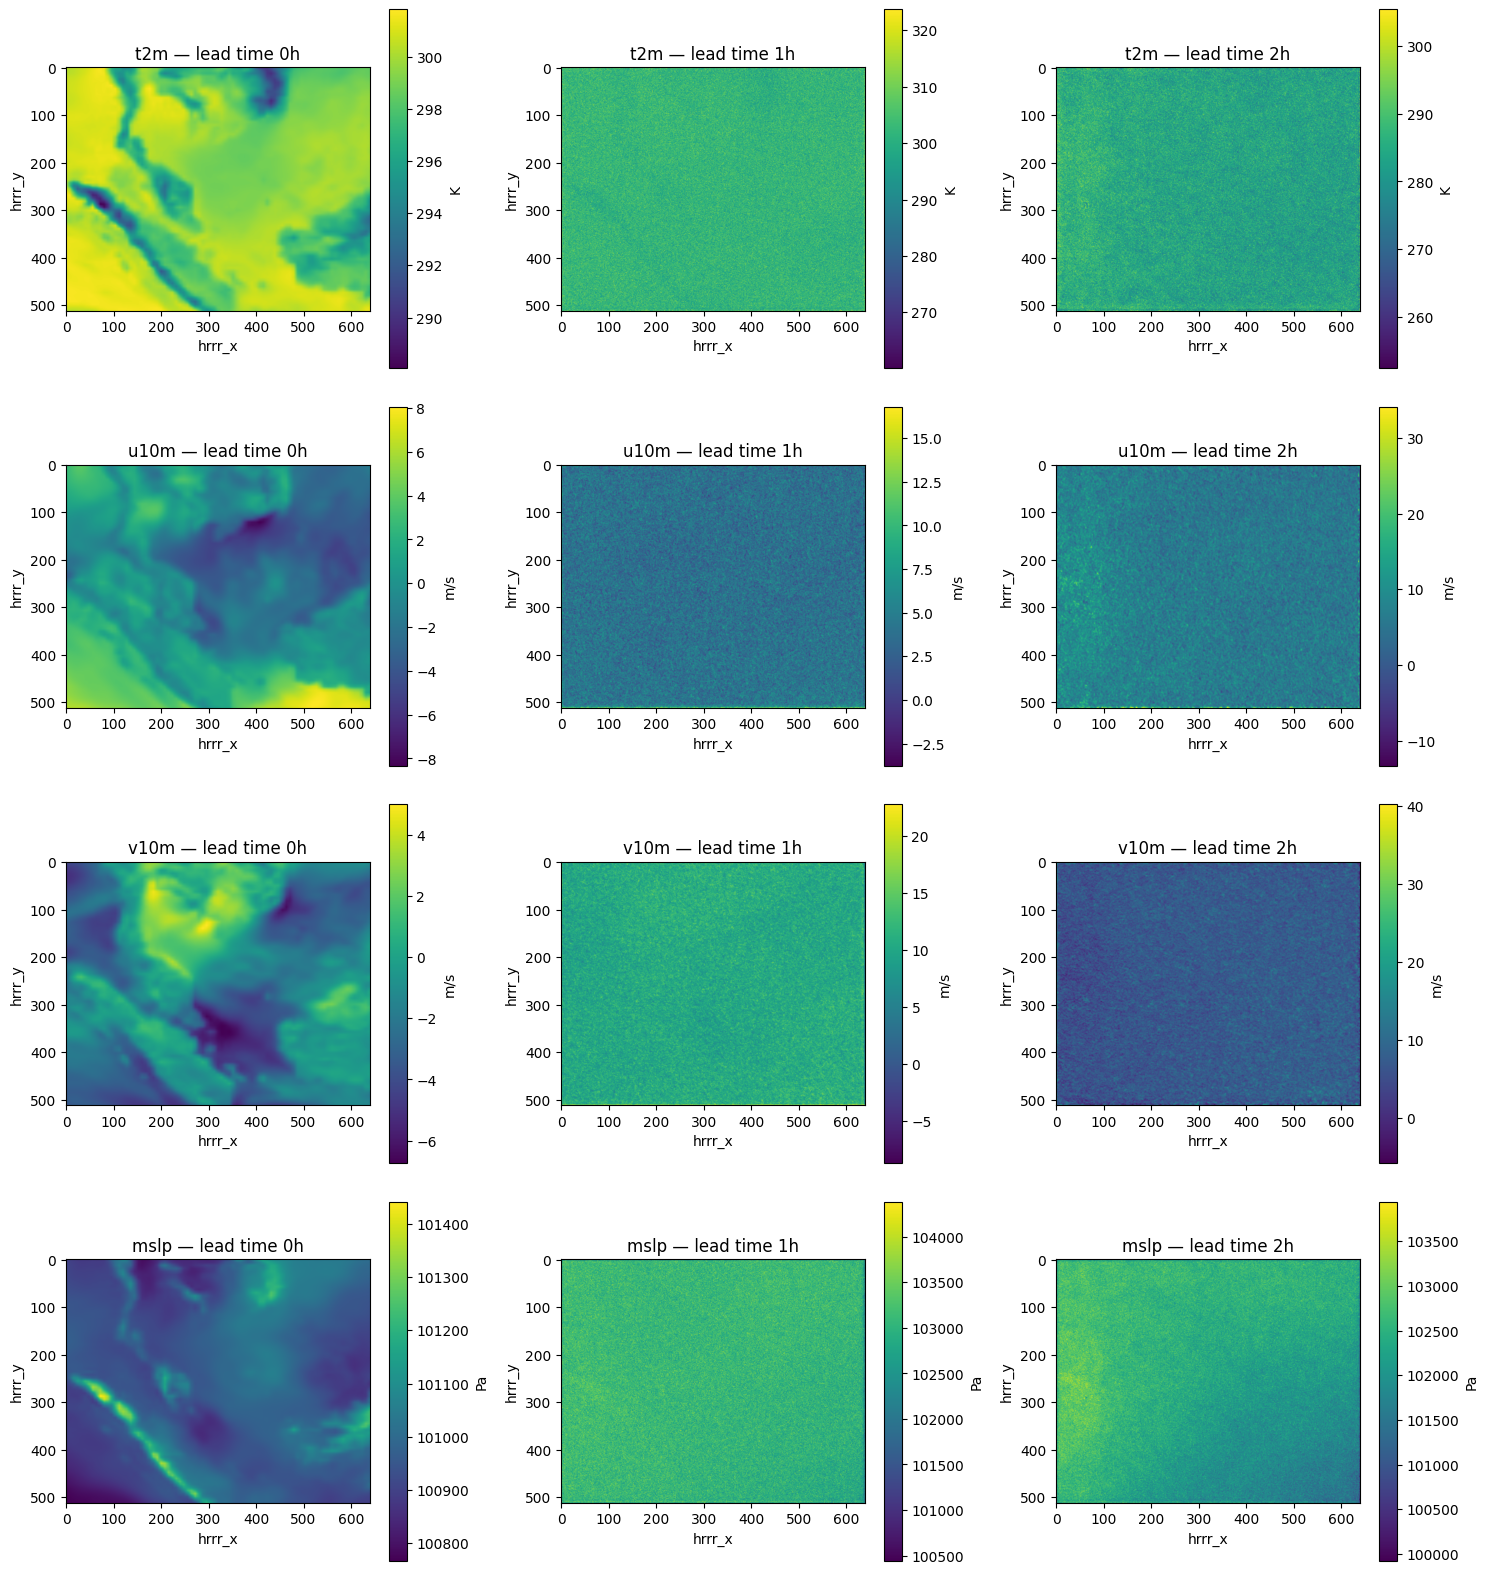

In [24]:
# ── 8. Plot output ────────────────────────────────────────────────────────────

ds_out = xr.open_zarr("stormcast_output_era5.zarr")

PLOT_VARIABLES = ["t2m", "u10m", "v10m", "mslp"]

n_leads = ds_out.sizes["lead_time"]
n_vars = len(PLOT_VARIABLES)

fig, axes = plt.subplots(
    n_vars,
    n_leads,
    figsize=(5 * n_leads, 4 * n_vars),
    squeeze=False,
)

for row, var_name in enumerate(PLOT_VARIABLES):
    for col in range(n_leads):
        field = ds_out[var_name].isel(time=0, lead_time=col).values

        im = axes[row, col].imshow(field, origin="upper")
        axes[row, col].set_title(f"{var_name} — lead time {col}h")
        axes[row, col].set_xlabel("hrrr_x")
        axes[row, col].set_ylabel("hrrr_y")

        cbar = plt.colorbar(im, ax=axes[row, col])

        UNITS = {"t2m": "K", "u10m": "m/s", "v10m": "m/s", "mslp": "Pa"}
        cbar.set_label(UNITS.get(var_name, var_name))

plt.tight_layout()
plt.show()